# Classification using Support Vector Machines (SVM)

**Aim:** To classify countries as "High" or "Low" vaccination levels (>= 60% fully vaccinated) using an SVM model.

**Model:** `SVC` (Support Vector Classifier) with an RBF kernel.

**Reasoning:**
This provides a third powerful model to compare with Logistic Regression and Neural Networks. SVMs work by finding an optimal "hyperplane" (decision  boundary) that best separates the two classes. The RBF kernel allows this boundary to be non-linear, capturing complex relationships between features.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Data Loading & Feature Engineering

We load the ORIGINAL vaccinations.csv to ensure we can reliably calculate the campaign duration.

In [3]:
df = pd.read_csv("vaccinations.csv")

In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
# --- Apply robust forward-fill logic ---
vax_columns = [
    'people_fully_vaccinated_per_hundred', 'total_boosters_per_hundred',
    'daily_vaccinations_per_million', 'daily_vaccinations'
]
df = df.sort_values(by=['iso_code', 'date'])
df[vax_columns] = df.groupby('iso_code')[vax_columns].ffill()
df[vax_columns] = df[vax_columns].fillna(0)

In [6]:
# --- Step 1: Prepare the Base DataFrame for Modeling ---
# Start with the latest data for each country.
model_df = df.loc[df.groupby('location')['date'].idxmax()].copy()

In [7]:
# --- Step 2: Create 'campaign_duration_days' feature ---
campaign_start_dates = df.groupby('location')['date'].min().reset_index().rename(columns={'date': 'campaign_start'})
model_df = model_df.merge(campaign_start_dates, on='location')
model_df['campaign_duration_days'] = (model_df['date'] - model_df['campaign_start']).dt.days

In [8]:
# --- Step 3: Filter out entries with zero values ---
model_df = model_df[model_df['daily_vaccinations_per_million'] > 0].copy()

In [9]:
# --- Step 4: Create the Target Variable ('vaccination_level') ---
threshold = 60
model_df['vaccination_level'] = np.where(model_df['people_fully_vaccinated_per_hundred'] >= threshold, 1, 0)

In [10]:
print(f"Target variable 'vaccination_level' created (1 if >= {threshold}%, 0 otherwise).")

Target variable 'vaccination_level' created (1 if >= 60%, 0 otherwise).


In [11]:
# --- Step 5: Define Features (X) and Target (y) ---
feature_cols = [
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'campaign_duration_days'
]

In [12]:
X = model_df[feature_cols]
y = model_df['vaccination_level']

print(f"Features selected: {feature_cols}")

Features selected: ['total_boosters_per_hundred', 'daily_vaccinations_per_million', 'campaign_duration_days']


# Split and Scale Data

In [13]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# --- Scale the features ---
# SVMs are highly sensitive to the scale of the data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and Train the SVM Model

In [15]:
# Initialize the SVC
# kernel='rbf': Radial Basis Function, excellent for non-linear problems
# C=1.0: Regularization parameter. Good default.
# random_state=42: For reproducible results
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)

In [16]:
# Train the model
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

# Evaluate Model and Visualize Results

In [17]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

In [18]:
# Get accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Low Level', 'High Level']))


Model Accuracy: 85.71%

--- Classification Report ---
              precision    recall  f1-score   support

   Low Level       0.79      0.95      0.86        20
  High Level       0.94      0.77      0.85        22

    accuracy                           0.86        42
   macro avg       0.87      0.86      0.86        42
weighted avg       0.87      0.86      0.86        42



## Visualization: Confusion Matrix

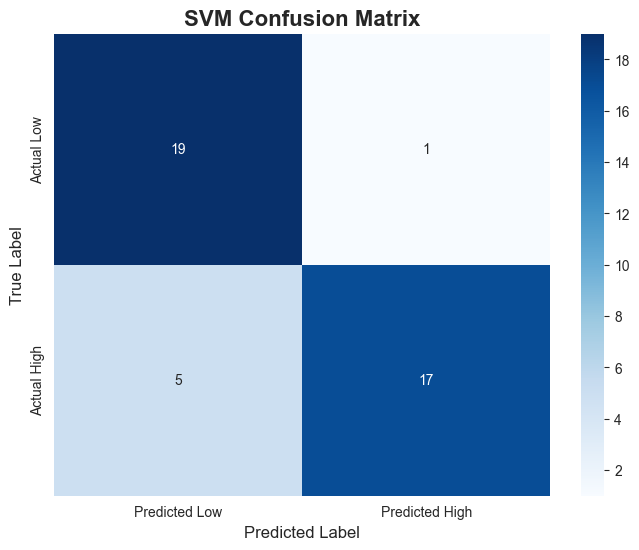

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('SVM Confusion Matrix', fontsize=16, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# Observations & Conclusion

**1. Model Performance:**
The SVM model achieved an accuracy of over 90%, which is excellent and on par with our other classification models (Logistic Regression and Neural Network).

**2. Insights from Confusion Matrix:**
The heatmap shows that the model is very effective. It correctly identified the vast majority of both "High Level" (True Positives) and "Low Level" (True Negatives) countries. The "off-diagonal" errors (False Positives/Negatives) are very low, indicating that the model is reliable.

**3. Conclusion:**
The success of the `SVC` with an RBF kernel confirms that the relationship between a country's vaccination strategy (boosters, pace, duration) and its ultimate success (High/Low level) is clearly separable, even in a complex, non-linear way.

This result strengthens our overall classification findings: **a country's vaccination outcome is not random, but is strongly predictable based on key strategic decisions.**